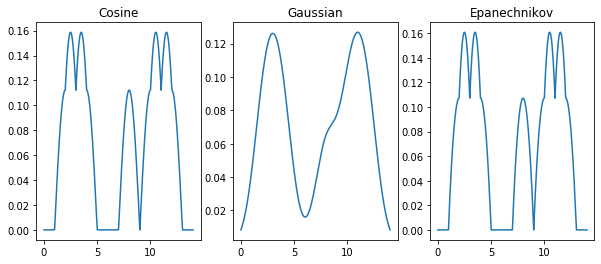

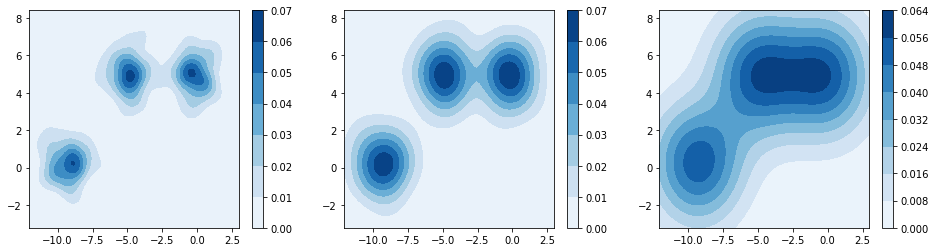

In [55]:
import pandas as pd
import numpy as np
from scipy.stats import multivariate_normal, norm
import matplotlib.pyplot as plt
from math import *


# implement consine kernel
def cosine_kernel(x, train, h):
    # x: test point
    # train: training set
    # h: bandwidth
    # return p(x)
    p=[]
    for i in x:
        temp = 0
        for j in train:
            if abs((i-j)/h)<=1:
                u = (i-j)/h
                temp += (pi/4)*cos((pi/2)*u)
        p.append(temp)
    return p    
    

# implement gaussian kernel
def gaussian_kernel(x, train, h):
    # x: test point
    # train: training set
    # h: bandwidth
    # return p(x)
    m = np.mean(train)
    v = np.var(train)
    p=[]
    for i in x:
        temp = 0
        for j in train:
            temp += (1/np.sqrt(2*pi))*(exp(-(((i-j)/h)**2)/2))
        p.append(temp)
    return p    
    

# implement 2D gaussian kernel
def gaussian_2d_kernel(x, train, h):
    # x: test point
    # train: training set
    # h: bandwidth
    # return p(x)
    m = np.mean(train)
    v = np.var(train)
    p=[]
    for i in x:
        temp = 0
        for j in train:
            distance = sqrt((i[0]-j[0])**2+(i[1]-j[1])**2)
            temp+=(1/np.sqrt(2*pi))*(exp(-(((distance)/h)**2)/2))
        p.append(temp)
    return p    

# implement epanechnikov kernel
def epanechnikov_kernel(x,train,h):
    # x: test point
    # train: training set
    # h: bandwidth
    # return p(x)
    m = np.mean(train)
    v = np.var(train)
    p=[]
    for i in x:
        temp = 0
        for j in train:
            if abs((i-j)/h)<=1:
                u = (i-j)/h
                temp += (3/4)*(1-(u**2))
        p.append(temp)
    return p    
    
    
def kde1d(train,test,kernel,h):
    # train: training set
    # test: test set
    # kernel: kernel function (object)
    # h: bandwidth
    # return d, d contains probaiblity density values of test samples (1d array)
    d = kernel(test,train,h)
    for i in range(len(d)):
        d[i] = (d[i]/h)/len(train)
    return d

def kde2d(train,test,kernel,h):
    # train: training set
    # test: test set
    # kernel: kernel function (object)
    # h: bandwidth
    # return d, d contains probaiblity density values of test samples (1d array)
    d = kernel(test,train,h)
    for i in range(len(d)):
        d[i] = (d[i]/h)/len(train)
    return d

# 1D
sample=[2,3,4,8,10,11,12]
h=1
x=np.linspace(0,14,100000)

y1=kde1d(sample,x,cosine_kernel,h)
y2=kde1d(sample,x,gaussian_kernel,h)
y3=kde1d(sample,x,epanechnikov_kernel,h)
    
fig=plt.subplots(1,3,figsize=(10,4))
plt.subplot(1,3,1)
plt.plot(x,y1)
plt.title('Cosine')
plt.subplot(1,3,2)
plt.plot(x,y2)
plt.title('Gaussian')
plt.subplot(1,3,3)
plt.plot(x,y3)
plt.title('Epanechnikov')
plt.show()

#2D
sample_2d=pd.read_csv(r'https://drive.google.com/uc?export=download&id=1uyPHjquXOIS9TTrG9Nb_gW3sfQEOdY0V')
sum_stats=sample_2d.describe()
xmin,ymin=sum_stats.loc['min']-0.5
xmax,ymax=sum_stats.loc['max']+0.5

x=np.linspace(xmin,xmax,100)
y=np.linspace(ymin,ymax,100)
X,Y=np.meshgrid(x,y)
Z = np.c_[X.ravel(),Y.ravel()]

Z1 = kde2d(sample_2d.values,Z,gaussian_2d_kernel,0.5)
Z1 = np.reshape(Z1, X.shape)
Z2 = kde2d(sample_2d.values,Z,gaussian_2d_kernel,1)
Z2 = np.reshape(Z2, X.shape)
Z3 = kde2d(sample_2d.values,Z,gaussian_2d_kernel,2)
Z3 = np.reshape(Z3, X.shape)

fig,ax=plt.subplots(1,3,figsize=(16,4))
plt.subplot(1,3,1)
cs=plt.contourf(X,Y,Z1,cmap=plt.cm.Blues)
plt.colorbar(cs)
plt.subplot(1,3,2)
cs=plt.contourf(X,Y,Z2,cmap=plt.cm.Blues)
plt.colorbar(cs)
plt.subplot(1,3,3)
cs=plt.contourf(X,Y,Z3,cmap=plt.cm.Blues)
plt.colorbar(cs)
plt.show()

